# 实验五：图像退化与复原

**实验目的：**
理解图像退化模型 $g(x,y) = f(x,y) * h(x,y) + n(x,y)$，掌握逆滤波与维纳滤波的基本原理。

**实验准备：**
请确保当前目录下有一张名为 `lena.jpg` 的清晰图像。


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def show_images(images, titles, figsize=(15, 5)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# 读取原始图像并转为灰度图
img = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("⚠️ 找不到 lena.jpg，请准备一张图片并重命名为 lena.jpg！")
else:
    print(f"图像读取成功！尺寸: {img.shape}")


图像读取成功！尺寸: (240, 320)


## 1. 模拟图像退化过程：运动模糊 + 高斯噪声
首先，我们需要构造一个“点扩散函数”（PSF，对应公式里的 $h(x,y)$），这里我们模拟相机沿对角线移动产生的运动模糊。
然后，我们将模糊后的图像加入高斯噪声 $n(x,y)$。
[Image of image restoration degradation model]


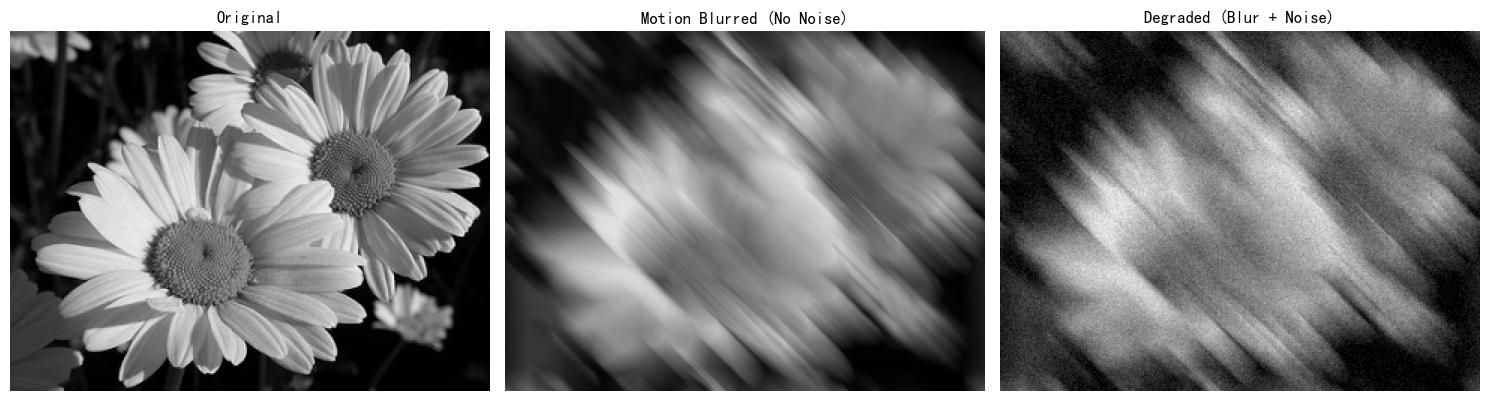

In [2]:
if img is not None:
    rows, cols = img.shape

    # 1. 构造运动模糊的 PSF (点扩散函数)
    psf = np.zeros((rows, cols), dtype=np.float32)
    # 在中心画一条对角线代表相机的运动轨迹
    length = 30
    cv2.line(psf, (cols//2 - length//2, rows//2 - length//2), 
                  (cols//2 + length//2, rows//2 + length//2), 1, 1)
    psf /= psf.sum() # 归一化，保证图像亮度不发生变化

    # 2. 将图像和 PSF 转换到频域，进行点乘模糊 (频域相乘 = 空域卷积)
    F = np.fft.fft2(img)
    # 注意：一定要把 PSF 的中心移到左上角原点，否则复原时图像会发生平移
    H = np.fft.fft2(np.fft.ifftshift(psf)) 

    G_blur = F * H
    img_blur = np.abs(np.fft.ifft2(G_blur))

    # 3. 添加高斯噪声
    noise = np.random.normal(0, 10, img.shape)
    img_degraded = np.clip(img_blur + noise, 0, 255)

    # 把退化图像转回频域，供后面复原使用
    G = np.fft.fft2(img_degraded)

    show_images([img, img_blur, img_degraded], 
                ["Original", "Motion Blurred (No Noise)", "Degraded (Blur + Noise)"])


## 2. 逆滤波复原 (Inverse Filtering)
退化公式的频域表示为：$G(u,v) = F(u,v)H(u,v) + N(u,v)$。
如果我们直接除以 $H(u,v)$ 来估算原图：$\hat{F}(u,v) = rac{G(u,v)}{H(u,v)} = F(u,v) + rac{N(u,v)}{H(u,v)}$。
**现象预告：** 因为 $H(u,v)$ 在高频处的值往往非常小甚至接近0，这会导致噪声项 $rac{N(u,v)}{H(u,v)}$ 被无限放大，整个画面会被巨大的噪声淹没！
[Image of image restoration inverse filtering]


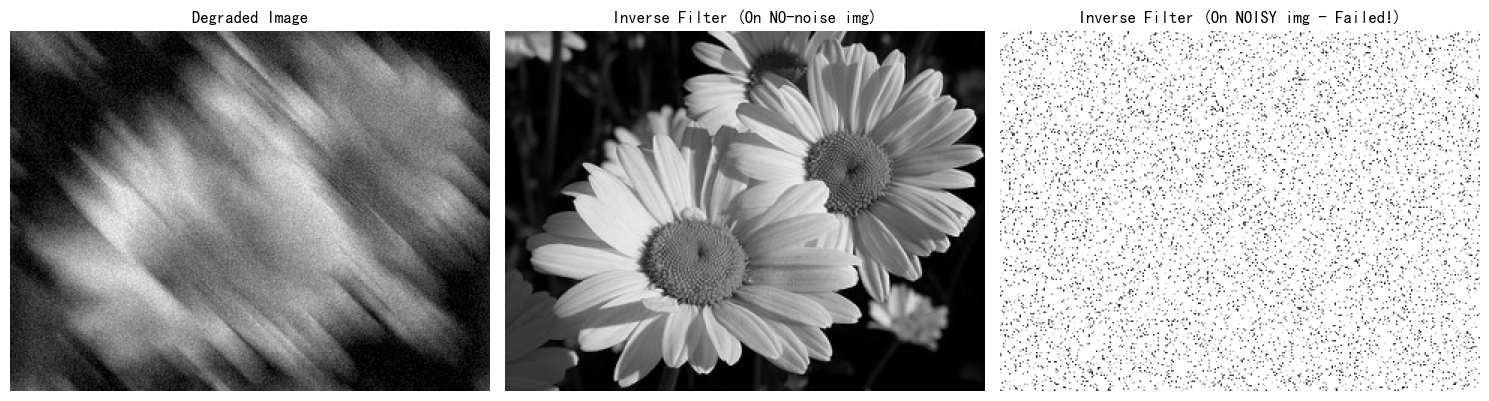

In [3]:
if img is not None:
    # 直接除以 H 会导致分母为 0 的问题，所以我们设一个非常小的阈值
    epsilon = 1e-3
    H_inv = np.zeros_like(H, dtype=complex)

    # 仅当 H 的幅度大于阈值时才进行倒数运算
    valid_idx = np.abs(H) > epsilon
    H_inv[valid_idx] = 1.0 / H[valid_idx]

    # 逆滤波重建
    F_inv = G * H_inv
    img_inv = np.abs(np.fft.ifft2(F_inv))
    img_inv = np.clip(img_inv, 0, 255)

    # 我们可以对比一下：如果没有噪声，直接逆滤波 img_blur 是什么效果
    F_inv_ideal = np.fft.fft2(img_blur) * H_inv
    img_inv_ideal = np.clip(np.abs(np.fft.ifft2(F_inv_ideal)), 0, 255)

    show_images([img_degraded, img_inv_ideal, img_inv], 
                ["Degraded Image", "Inverse Filter (On NO-noise img)", "Inverse Filter (On NOISY img - Failed!)"])


## 3. 维纳滤波复原 (Wiener Filtering)
为了克服逆滤波放大噪声的致命弱点，维纳滤波引入了一个参数 $K$ (常被视为噪信比)。
公式为：$H_{wiener} = rac{1}{H} \cdot rac{|H|^2}{|H|^2 + K}$。
当 $K=0$ 时，它退化为逆滤波；当存在噪声时，适当的 $K$ 值能极大地压制被放大的高频噪声。
[Image of Wiener filtering block diagram]


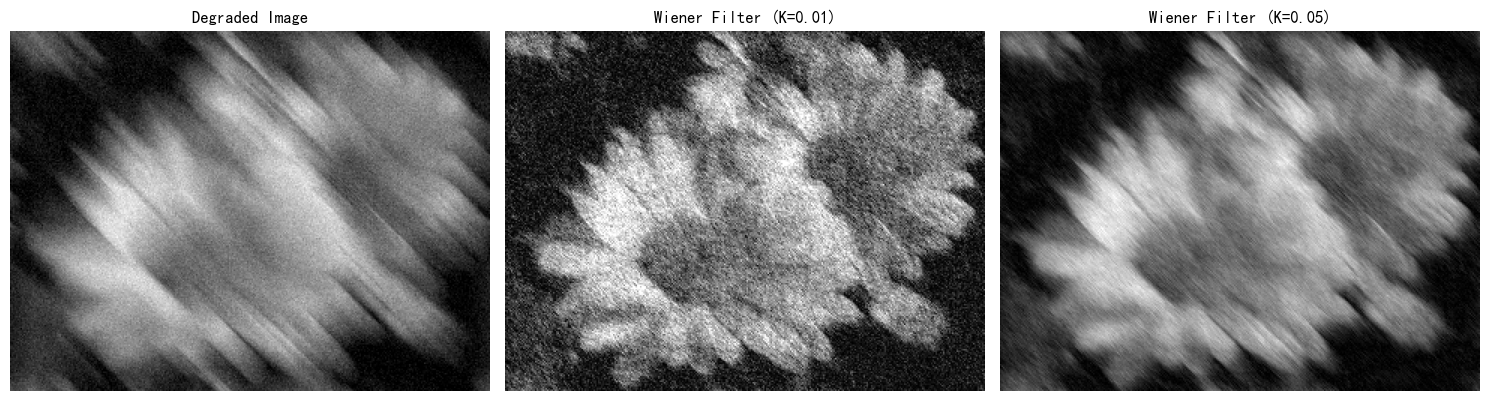

💡 结论：对比逆滤波那满屏的雪花点，维纳滤波成功地从模糊和噪声的混合体中，重新提取出了轮廓！


In [5]:
if img is not None:
    def wiener_filter(G, H, K):
        # 维纳滤波器计算
        H_wiener = np.conj(H) / (np.abs(H)**2 + K)
        # 应用滤波并逆变换
        F_wiener = G * H_wiener
        return np.clip(np.abs(np.fft.ifft2(F_wiener)), 0, 255)

    # 尝试不同的 K 值 (信噪比的倒数)
    img_wiener_k1 = wiener_filter(G, H, K=0.01)
    img_wiener_k2 = wiener_filter(G, H, K=0.05)

    show_images([img_degraded, img_wiener_k1, img_wiener_k2], 
                ["Degraded Image", "Wiener Filter (K=0.01)", "Wiener Filter (K=0.05)"])

    print("💡 结论：对比逆滤波那满屏的雪花点，维纳滤波成功地从模糊和噪声的混合体中，重新提取出了轮廓！")
